### Import necessary libraries

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.colors as mcolors

### Load separate datasets and combine (do not rerun)

In [2]:
ds_gofs = xr.open_dataset('traj_ds_GOFS.nc')
ds_nextsimf = xr.open_dataset('traj_ds_nextsimf.nc')
ds_riops = xr.open_dataset('traj_ds_RIOPS.nc')
ds_riops_coupled = xr.open_dataset('traj_ds_RIOPScoupled.nc')
ds_roms = xr.open_dataset('traj_ds_roms_no_vars.nc')
ds_topaz5 = xr.open_dataset('traj_ds_TOPAZ5.nc')
ds_hycom = xr.open_dataset('traj_ds_DMI-HYCOM.nc')

In [3]:
dataset = xr.merge([ds_gofs, ds_nextsimf, ds_riops, ds_riops_coupled, ds_roms, ds_topaz5, ds_hycom])

In [4]:
# remove wrong coordinate in datasets
exclude_models = ['MET-ROMS_m01, MET-LAON']
dataset = dataset.sel(model=~dataset.model.isin(exclude_models))

In [5]:
dff = xr.open_dataset('../traj_dataset_final.nc')

In [6]:
# add satellite data
dataset['AMSR2_SIC'] = dff['AMSR2_SIC'].copy()
dataset['MODIS_Ts'] = dff['MODIS_Ts'].copy()

In [8]:
dataset.to_netcdf('traj_ds_GOFS_NexSIM_RIOPS_RIOPScoupled_ROMS_TOPAZ5_HYCOM.nc')

### Open combined dataset

In [2]:
dataset = xr.open_dataset('traj_ds_GOFS_NexSIM_RIOPS_RIOPScoupled_ROMS_TOPAZ5_HYCOM.nc')

## Plot of observed and simulated longitude and latitude over time for one complete forecast

Text(0.5, 1.0, 'Observed and simulated longitude of buoy 3 from 2024-04-16')

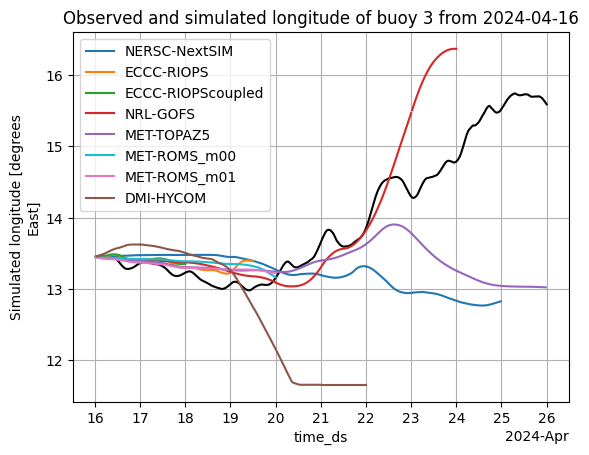

In [8]:
buoy_nr = 3
buoy_data = dataset.sel(tr_nr = buoy_nr)

colors = {
    'NERSC-NextSIM': 'tab:blue',
    'ECCC-RIOPS': 'tab:orange',
    'ECCC-RIOPScoupled': 'tab:green',
    'NRL-GOFS': 'tab:red',
    'MET-TOPAZ5': 'tab:purple',
    'MET-ROMS_m00': 'tab:cyan',
    'MET-ROMS_m01': 'tab:pink',
    'DMI-HYCOM': 'tab:brown'
}

#['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01']
#models_sel = []
models_sel = ['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01', 'DMI-HYCOM']
target_date = '2024-04-16'  # Example date in YYYY-MM-DD format

lon_obs_b, lat_obs_b = buoy_data['lon_obs'], buoy_data['lat_obs']
plt.figure()
start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1)
end = start + pd.DateOffset(days=10)
        
lon_obs_b.sel(time_ds=slice(start,end)).plot(color='k')
for model_name in models_sel:
    color = colors.get(model_name, 'black')
    
    # Plot dummy line for legend
    plt.plot([], [], color=color, label=model_name)
    
    for k in range(0,10):
        lt_int_sel = dataset['lt_int'].values[k]
        start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1) + pd.DateOffset(days=k) 
        end = start + pd.DateOffset(days=1)
        lon_sim_lt_k = buoy_data['lon_sim'].sel(model=model_name, time_ds=slice(start,end), lt_int=lt_int_sel)
        lat_sim_lt_k = buoy_data['lat_sim'].sel(model=model_name, time_ds=slice(start,end), lt_int=lt_int_sel)
        lon_sim_lt_k.plot(color=color)

plt.legend(loc='upper left')
plt.grid(True)
plt.title(f'Observed and simulated longitude of buoy {buoy_nr} from {target_date}')

Text(0.5, 1.0, 'Observed and simulated latitude of buoy 3 from 2024-04-20')

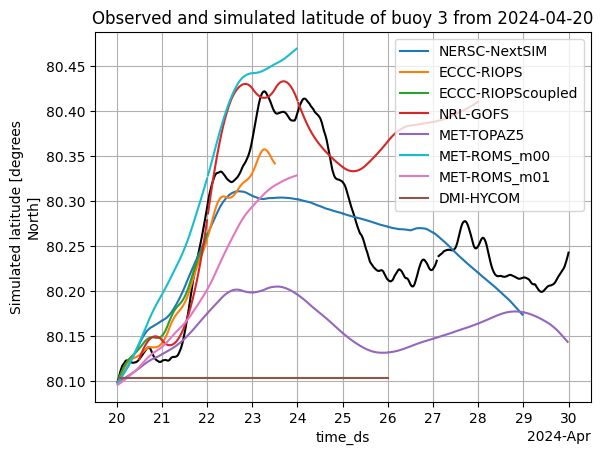

In [13]:
## buoy_nr = 3
buoy_data = dataset.sel(tr_nr = buoy_nr)

colors = {
    'NERSC-NextSIM': 'tab:blue',
    'ECCC-RIOPS': 'tab:orange',
    'ECCC-RIOPScoupled': 'tab:green',
    'NRL-GOFS': 'tab:red',
    'MET-TOPAZ5': 'tab:purple',
    'MET-ROMS_m00': 'tab:cyan',
    'MET-ROMS_m01': 'tab:pink',
    'DMI-HYCOM': 'tab:brown'
}

#['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01']
#models_sel = []
models_sel = ['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01', 'DMI-HYCOM']
target_date = '2024-04-20'  # Example date in YYYY-MM-DD format

lon_obs_b, lat_obs_b = buoy_data['lon_obs'], buoy_data['lat_obs']
plt.figure()
start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1)
end = start + pd.DateOffset(days=10)
        
lat_obs_b.sel(time_ds=slice(start,end)).plot(color='k')
for model_name in models_sel:
    color = colors.get(model_name, 'black')
    
    # Plot dummy line for legend
    plt.plot([], [], color=color, label=model_name)
    
    for k in range(0,10):
        lt_int_sel = dataset['lt_int'].values[k]
        start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1) + pd.DateOffset(days=k) 
        end = start + pd.DateOffset(days=1)
        lon_sim_lt_k = buoy_data['lon_sim'].sel(model=model_name, time_ds=slice(start,end), lt_int=lt_int_sel)
        lat_sim_lt_k = buoy_data['lat_sim'].sel(model=model_name, time_ds=slice(start,end), lt_int=lt_int_sel)
        lat_sim_lt_k.plot(color=color)

plt.legend(loc='upper right')
plt.grid(True)
plt.title(f'Observed and simulated latitude of buoy {buoy_nr} from {target_date}')

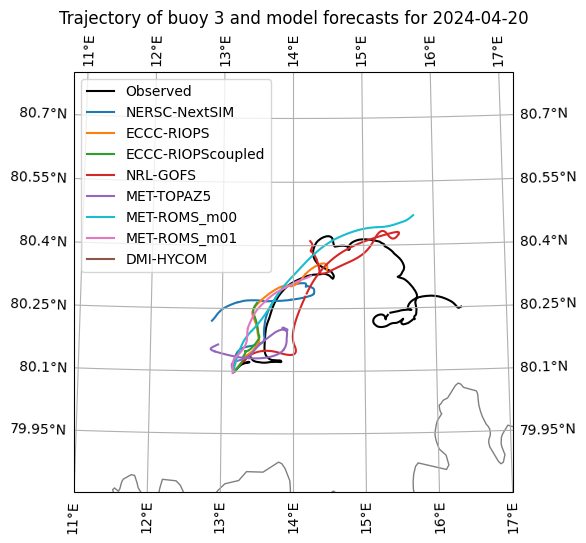

In [7]:
lt_int_sel = ']0_24]'
models_sel = ['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01', 'DMI-HYCOM']
colors = {
    'NERSC-NextSIM': 'tab:blue',
    'ECCC-RIOPS': 'tab:orange',
    'ECCC-RIOPScoupled': 'tab:green',
    'NRL-GOFS': 'tab:red',
    'MET-TOPAZ5': 'tab:purple',
    'MET-ROMS_m00': 'tab:cyan',
    'MET-ROMS_m01': 'tab:pink',
    'DMI-HYCOM': 'tab:brown'
}

centr_lon = 14
dlon = 3
centr_lat = 80.3
dlat = 1
projection = ccrs.LambertConformal(central_longitude=centr_lon, central_latitude=centr_lat)

fig = plt.figure(figsize=(13, 6))
ax_map = fig.add_axes([0.05, 0.15, 0.9, 0.7], projection=projection)
ax_map.set_extent([centr_lon - dlon, centr_lon + dlon, centr_lat - dlat/2, centr_lat + dlat/2], crs=ccrs.PlateCarree())
ax_map.add_feature(cf.COASTLINE, alpha=0.5)
ax_map.add_feature(cf.BORDERS, alpha=0.5)

buoy_nr = 3
buoy_data = dataset.sel(tr_nr = buoy_nr)
target_date = '2024-04-20'

start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1)
end = start + pd.DateOffset(days=8)
# Plot observed buoy trajectory
ax_map.plot(buoy_data['lon_obs'].sel(time_ds=slice(start,end)), buoy_data['lat_obs'].sel(time_ds=slice(start,end)), 'k-', label='Observed', transform=ccrs.PlateCarree())

# Plot model trajectories
for model_name in models_sel:
    color = colors.get(model_name, 'black')
    for k in range(8):
        lt_int_sel_k = dataset['lt_int'].values[k]
        start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1) + pd.DateOffset(days=k)
        end = start + pd.DateOffset(days=1)
        lon_sim = buoy_data['lon_sim'].sel(model=model_name, time_ds=slice(start, end), lt_int=lt_int_sel_k)
        lat_sim = buoy_data['lat_sim'].sel(model=model_name, time_ds=slice(start, end), lt_int=lt_int_sel_k)
        ax_map.plot(lon_sim, lat_sim, color=color, label=model_name if k == 0 else "", transform=ccrs.PlateCarree())

ax_map.set_title(f'Trajectory of buoy {buoy_nr} and model forecasts for {target_date}')
ax_map.legend(loc='upper left')
ax_map.gridlines(draw_labels=True, x_inline=False, y_inline=False)
plt.show()


## Plot forecasts with up to 24h lead time for one model

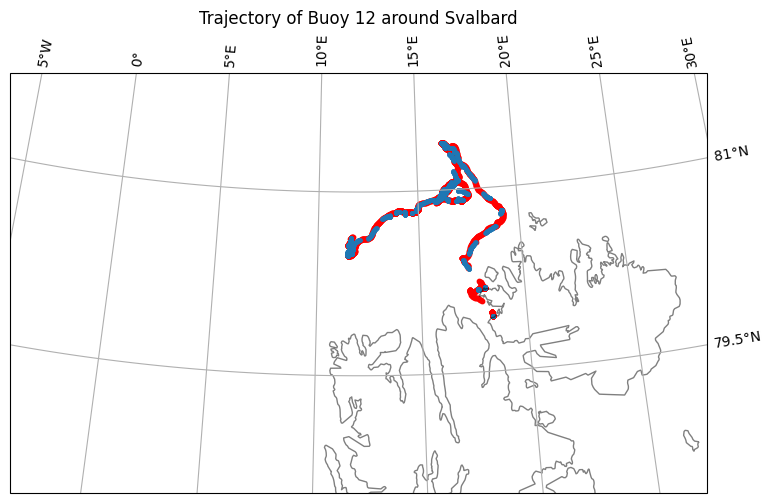

In [15]:
lt_int_sel = ']0_24]'
#models_sel = df.model.values
#models_sel = ['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01']
models_sel = ['NERSC-NextSIM']

# Define parameters used in plotting
centr_lon = 12
dlon = 15
centr_lat = 80
dlat = 3.5
projection = ccrs.LambertConformal(central_longitude=centr_lon, central_latitude=centr_lat)

# Prepare the figure
fig = plt.figure(figsize=(13, 6))
ax_map = fig.add_axes([0.05, 0.15, 0.9, 0.7], projection=projection)

# Set extent
ax_map.set_extent([centr_lon - dlon, centr_lon + dlon, centr_lat - dlat/2, centr_lat + dlat/2], crs=ccrs.PlateCarree())
ax_map.add_feature(cf.COASTLINE, alpha=0.5)
ax_map.add_feature(cf.BORDERS, alpha=0.5)

# Filter for buoy number 12
buoy_nr = 12
buoy_data = dataset.sel(tr_nr = buoy_nr)

# Plot the buoy trajectory
# Scatter plot for the buoy's latitude and longitude
sc = ax_map.scatter(buoy_data['lon_obs'], buoy_data['lat_obs'], c='red', label=f'Buoy {buoy_nr}', s=10, transform=ccrs.PlateCarree())
for model_name in models_sel:
    sc = ax_map.scatter(buoy_data['lon_sim'].sel(model=model_name, lt_int=lt_int_sel), buoy_data['lat_sim'].sel(model=model_name, lt_int=lt_int_sel), label=f'Buoy {buoy_nr} lead time {lt_int_sel} of model {model_name}', s=5, transform=ccrs.PlateCarree())

# Add gridlines
gl = ax_map.gridlines(draw_labels=True, x_inline=False, y_inline=False)
gl.top_labels = True
gl.bottom_labels = False
gl.right_labels = True
gl.left_labels = False
gl.ylines_right = False
gl.ylocator = plt.MaxNLocator(3)

# Optionally, add a title and legend
ax_map.set_title(f'Trajectory of Buoy {buoy_nr} around Svalbard')
#plt.legend(loc='lower left')

# Show the plot
plt.show()
